In [28]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from typing import Any
from sklearn.preprocessing import MinMaxScaler


sys.path.append(os.path.abspath(".."))
from src.utils.plot import plot_entire_distribution, plot_entire_boxplot, plot_distribution, plot_boxplot
from src.utils.preprocess import feature_engineering

pd.set_option('display.max_columns', None)

In [2]:
test_df = pd.read_csv(os.path.join("..", "data", "test.csv"))
train_df = pd.read_csv(os.path.join("..", "data", "train.csv"))

In [3]:
temp_df, scalers = feature_engineering(train_df)

In [4]:
temp_df.head()

,Age,Match Started,Minutes Played,Goals,Assists,Non-Penality Goals,Goals Per 90 Minutes,Assists Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,FW,MF,Squad_Rank,Experience Level,Penalty Kicker
0,24,0.026316,0.035253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.705882,0,1,9,0,0
1,21,0.657895,0.652468,1.945910,0.693147,1.945910,0.215111,0.039221,0.215111,0.246860,17.147715,0,1,10,3,0
2,21,0.000000,0.102233,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.068274,0,1,11,1,0
3,26,0.526316,0.496769,0.693147,0.693147,0.693147,0.048790,0.048790,0.048790,0.104360,16.906553,0,1,4,2,0
4,22,0.763158,0.683901,1.098612,0.693147,1.098612,0.076961,0.039221,0.076961,0.113329,17.370859,0,1,7,3,0


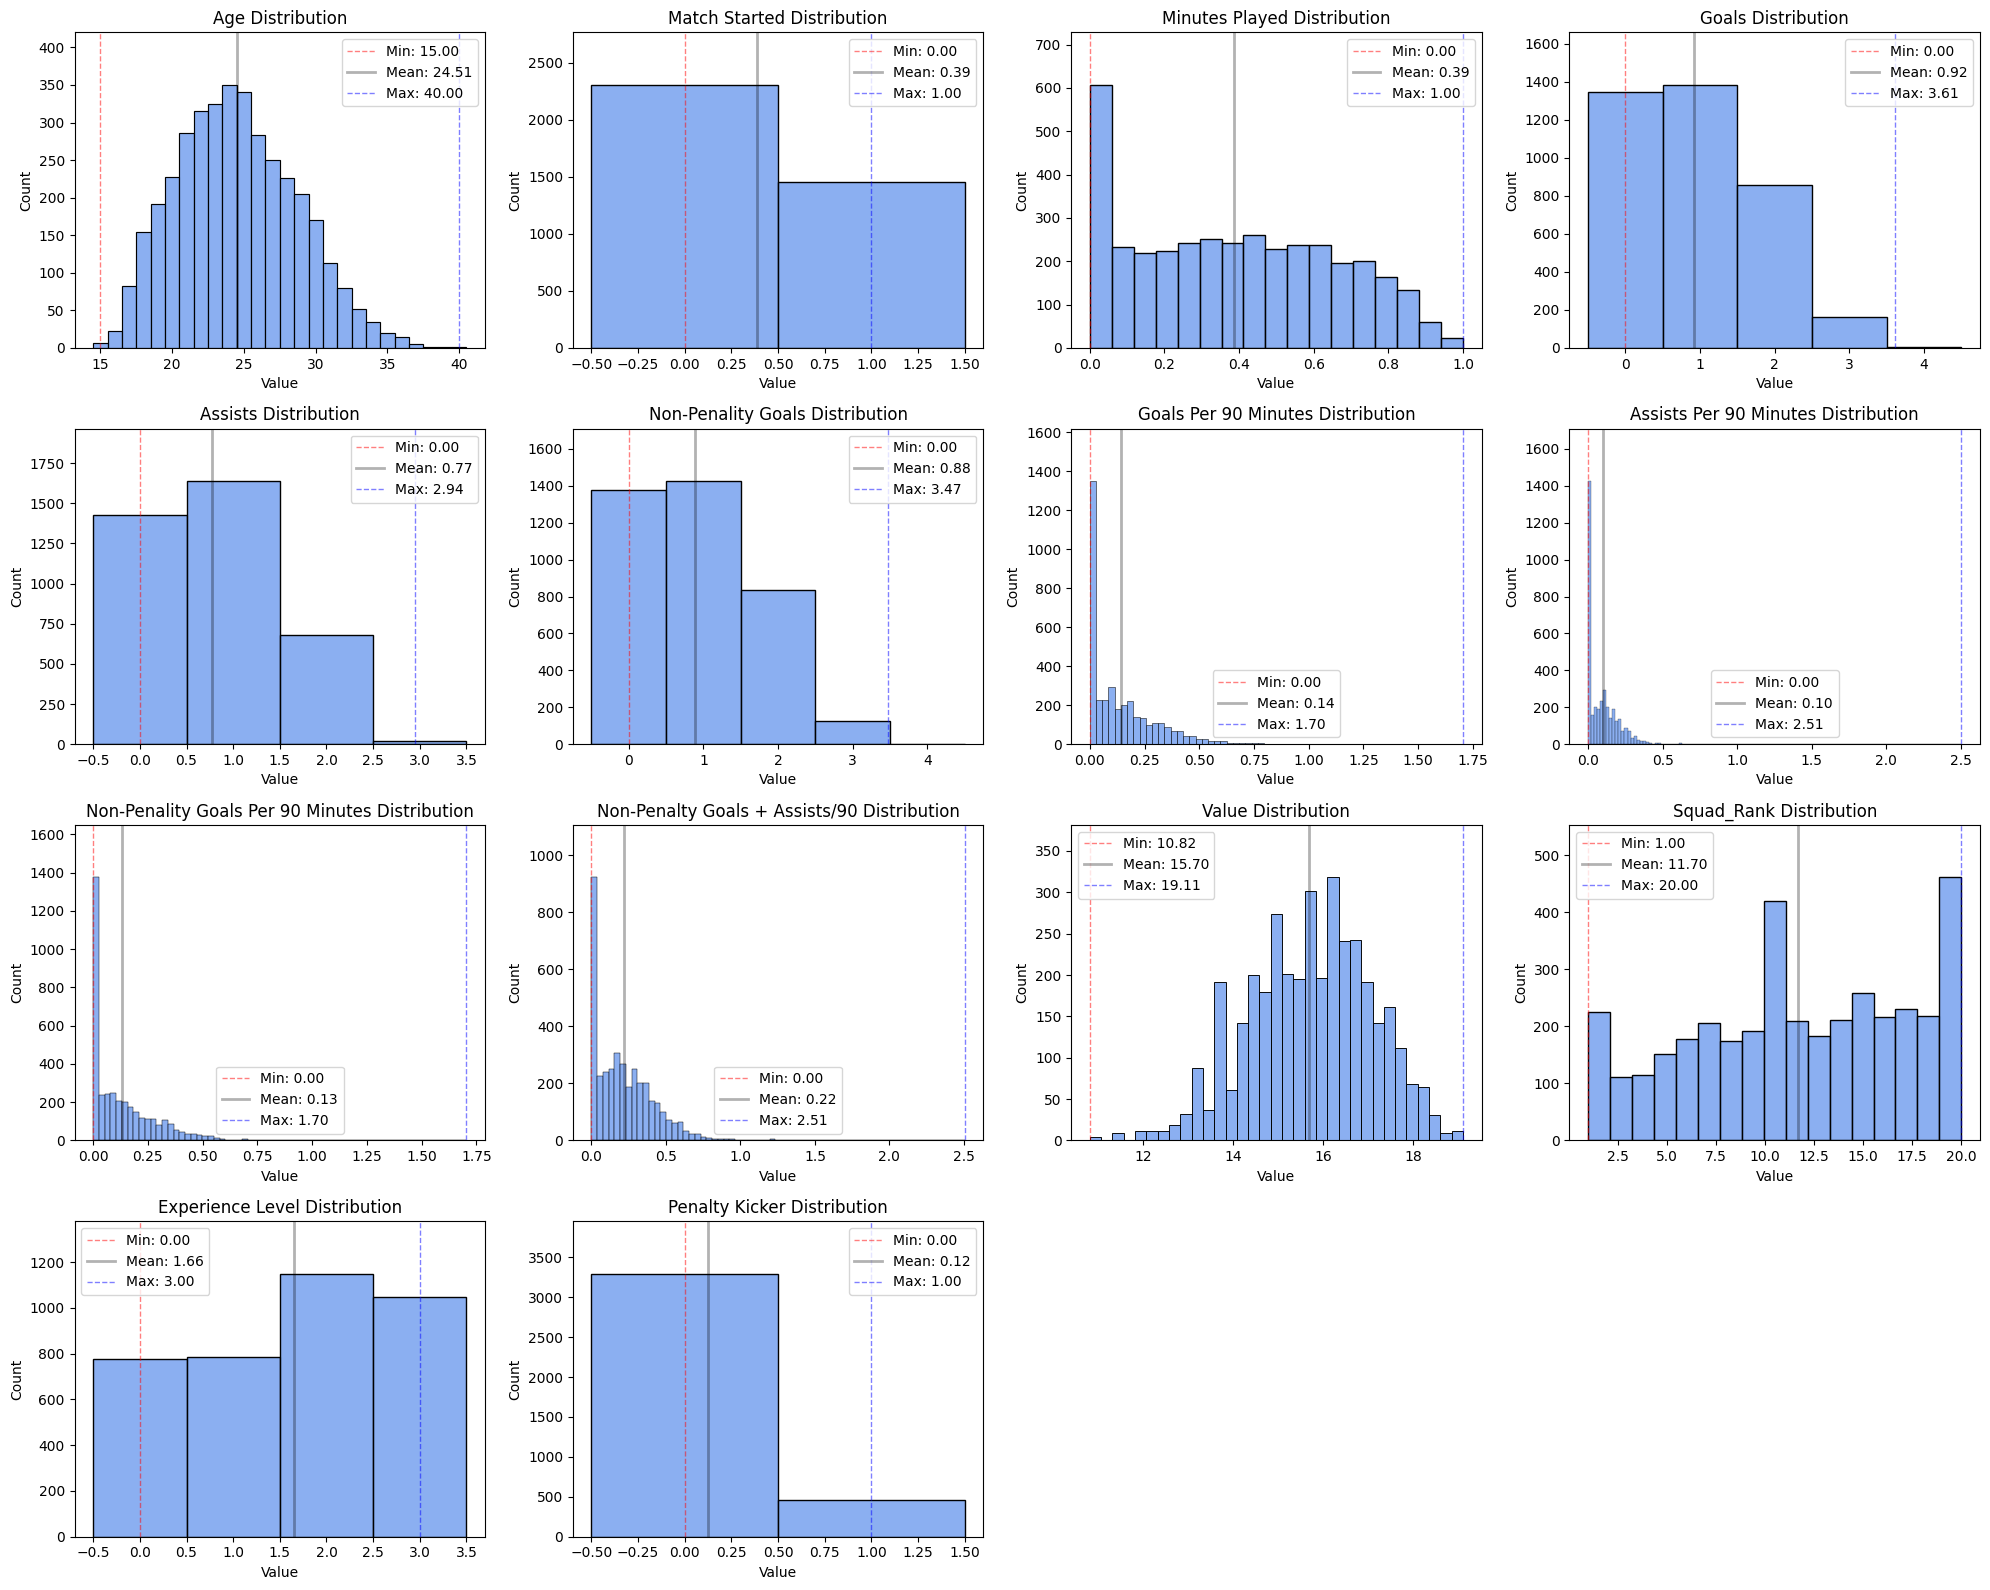

In [5]:
plot_entire_distribution(temp_df, color="cornflowerblue")

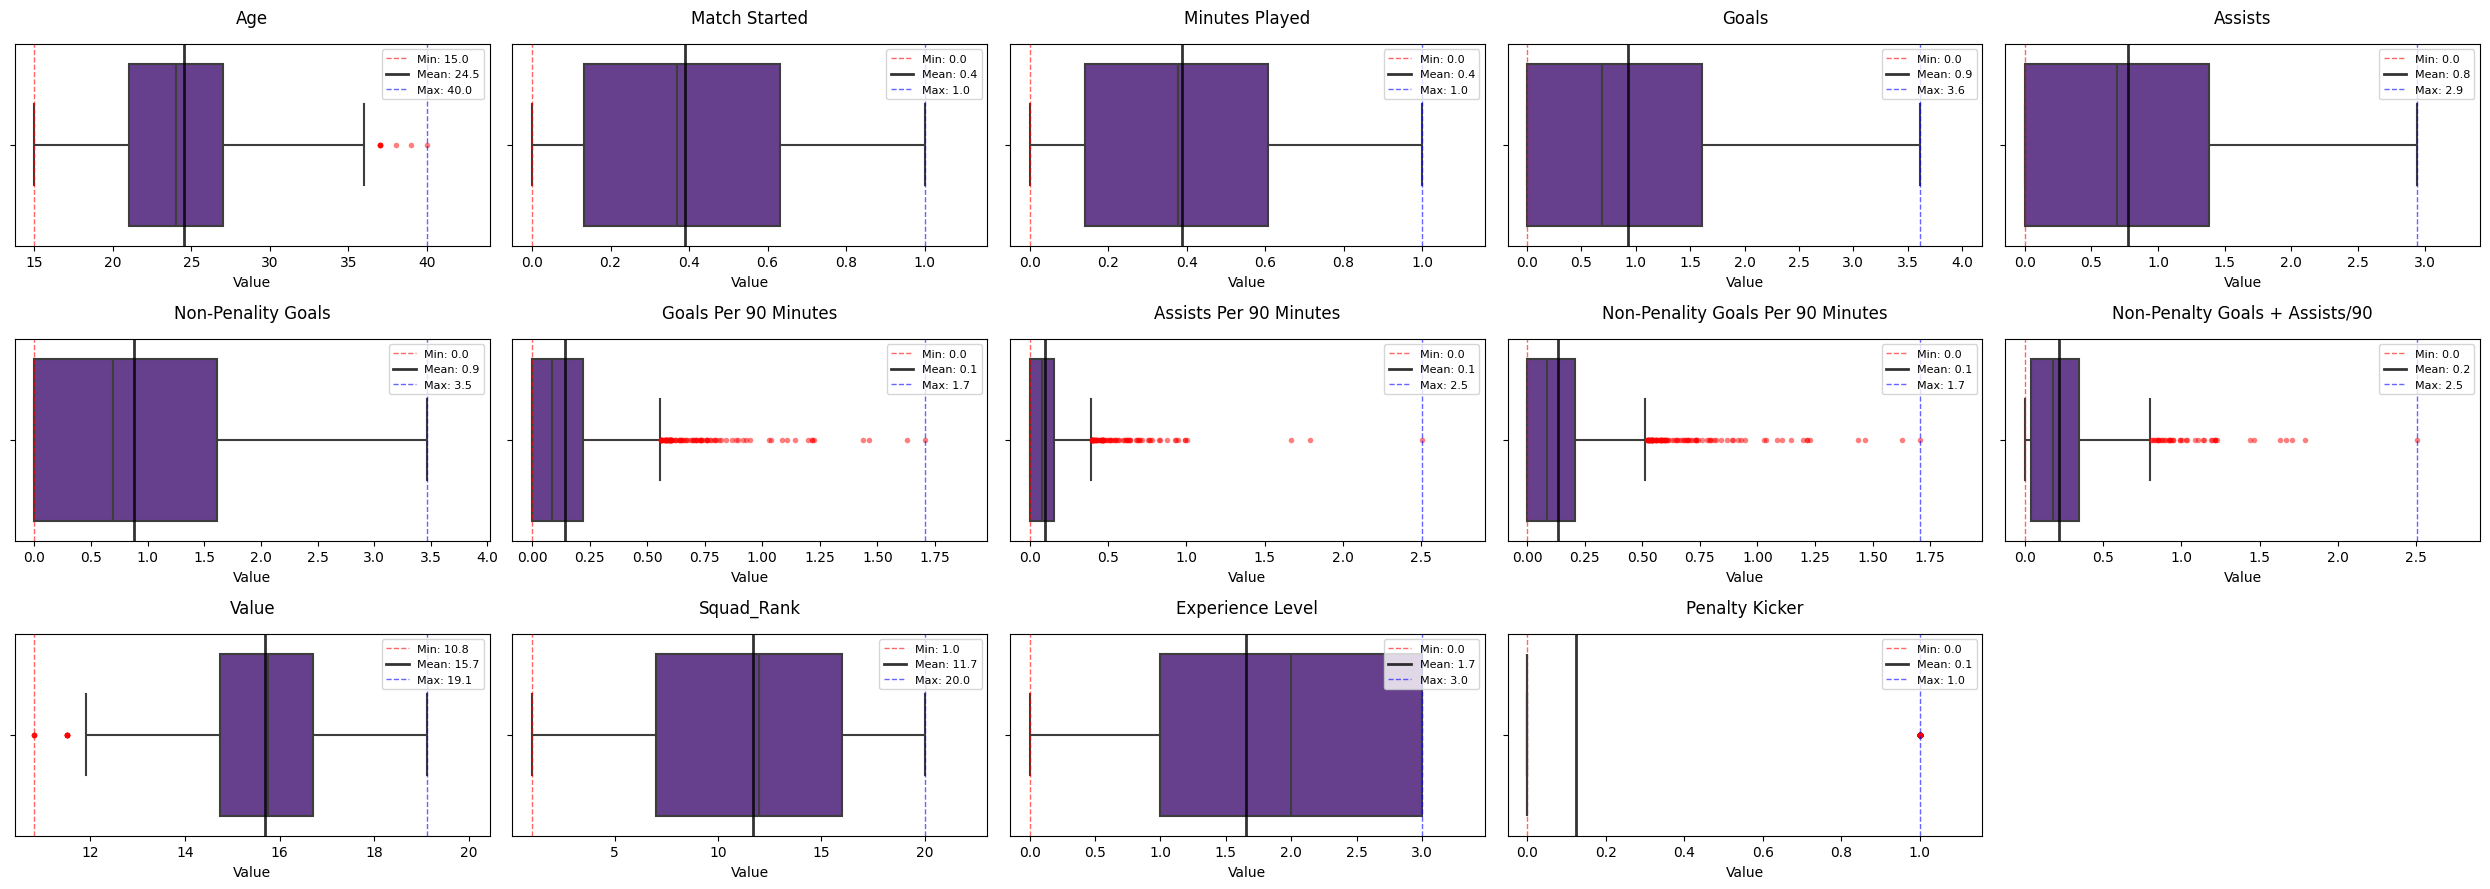

In [6]:
plot_entire_boxplot(temp_df)

In [7]:
# temp_df.head()
temp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3760 entries, 0 to 3759
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                3760 non-null   int64  
 1   Match Started                      3760 non-null   float64
 2   Minutes Played                     3760 non-null   float64
 3   Goals                              3760 non-null   float64
 4   Assists                            3760 non-null   float64
 5   Non-Penality Goals                 3760 non-null   float64
 6   Goals Per 90 Minutes               3760 non-null   float64
 7   Assists Per 90 Minutes             3760 non-null   float64
 8   Non-Penality Goals Per 90 Minutes  3760 non-null   float64
 9   Non-Penalty Goals + Assists/90     3760 non-null   float64
 10  Value                              3760 non-null   float64
 11  FW                                 3760 non-null   int64  
 12  MF 

In [8]:
temp_df.head()

,Age,Match Started,Minutes Played,Goals,Assists,Non-Penality Goals,Goals Per 90 Minutes,Assists Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,FW,MF,Squad_Rank,Experience Level,Penalty Kicker
0,24,0.026316,0.035253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.705882,0,1,9,0,0
1,21,0.657895,0.652468,1.945910,0.693147,1.945910,0.215111,0.039221,0.215111,0.246860,17.147715,0,1,10,3,0
2,21,0.000000,0.102233,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.068274,0,1,11,1,0
3,26,0.526316,0.496769,0.693147,0.693147,0.693147,0.048790,0.048790,0.048790,0.104360,16.906553,0,1,4,2,0
4,22,0.763158,0.683901,1.098612,0.693147,1.098612,0.076961,0.039221,0.076961,0.113329,17.370859,0,1,7,3,0


In [9]:
def feature_engineering(input_df: pd.DataFrame, scale=True, scalers: dict[Any] = None) -> tuple[pd.DataFrame, dict[Any]]:
    """
    1. Filters FW
    2. Drop Unused Columns
    3. Bin "Match Played"
    4. Binarize "Penalty Kick Goals"
    5. Log Transform "Goals", "Assists", "Non-Penalty Goals", "Goals Per 90 Minutes", "Assists Per 90 Minutes", "Non-Penalty Goals Per 90 Minutes", "Non-Penalty Goals + Assists/90"
    6. Min-Max Scale "Match Started", "Minutes Played"

    Parameters:
        input_df : dataframe loaded with train.csv or test.csv
        scale : Default to True. If True, returns dictionary containing the scaler with key 'mm_scaler'
        scalers : Default to None. Uses the provided scaler to when scaling. 

    Returns:
        1. feature engineered dataframe
        2. Dictionary containing scaler used
    """
    # Filter only FW & MF
    df = input_df[(input_df["FW"] == 1) | (input_df["MF"] == 1)].copy().reset_index(drop=True)
    df = df.drop(columns=["DF", "GK"])

    # Drop columns
    df = df.drop(columns=["Goals + Assists", "Penalty Kick Attempted", "Yellow Cards", "Red Cards", "G+A Per 90 Minutes", "Minutes Played / 90"])

    # Bin "Match Played"
    df["Experience Level"] = pd.cut(
        df["Match Played"], 
        bins=[0, 10, 20, 30, np.inf], 
        labels=["Level 1", "Level 2", "Level 3", "Level 4"],
        include_lowest=True,
    )
    df = df.drop(columns=["Match Played"])

    # Binarize "Penalty Kick Goals"
    df["Penalty Kicker"] = pd.cut(
        df["Penalty Kick Goals"], 
        bins=[0, 1, np.inf], 
        labels=["Not Penalty taker", "Penalty taker"],
        include_lowest=True,
        right = False,
    )
    df = df.drop(columns=["Penalty Kick Goals"])

    # Log Transform (f(x) = ln(x + 1)) "Goals", "Assists", "Non-Penalty Goals", "Goals Per 90 Minutes", "Assists Per 90 Minutes", "Non-Penalty Goals Per 90 Minutes", "Non-Penalty Goals + Assists/90"
    target_cols = ["Goals Per 90 Minutes", "Assists Per 90 Minutes", "Non-Penality Goals Per 90 Minutes", "Non-Penalty Goals + Assists/90", "Goals", "Assists", "Non-Penality Goals"]
    df[target_cols] = np.log1p(df[target_cols])

    # Min-Max Scale "Match Started", "Minutes Played"
    if scale:
        if scalers and ('mm_scaler' in scalers):
            df[["Match Started", "Minutes Played"]] = scalers['mm_scaler'].transform(df[["Match Started", "Minutes Played"]])
            return df, scalers
        else:
            scalers = {}

            mm_scaler = MinMaxScaler()
            df[["Match Started", "Minutes Played"]] = mm_scaler.fit_transform(df[["Match Started", "Minutes Played"]])

            scalers['mm_scaler'] = mm_scaler

            return df, scalers

    return df, scalers

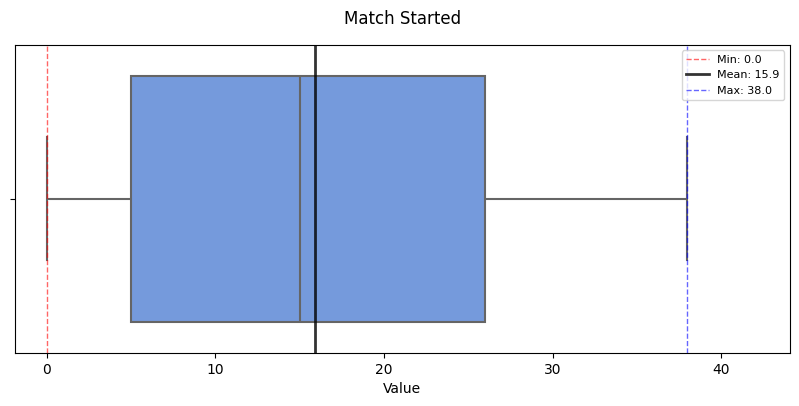

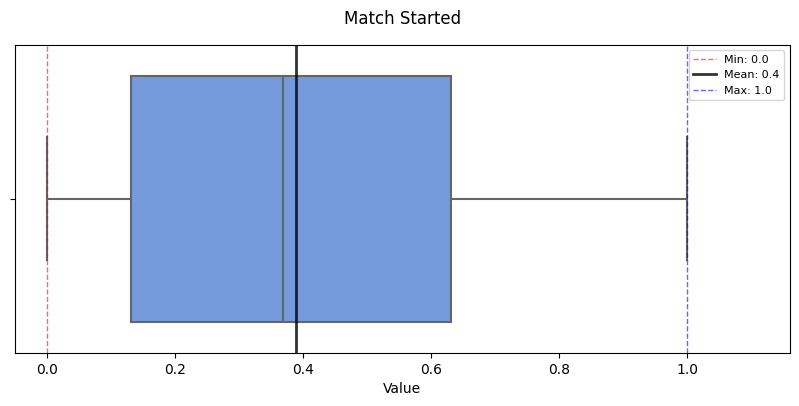

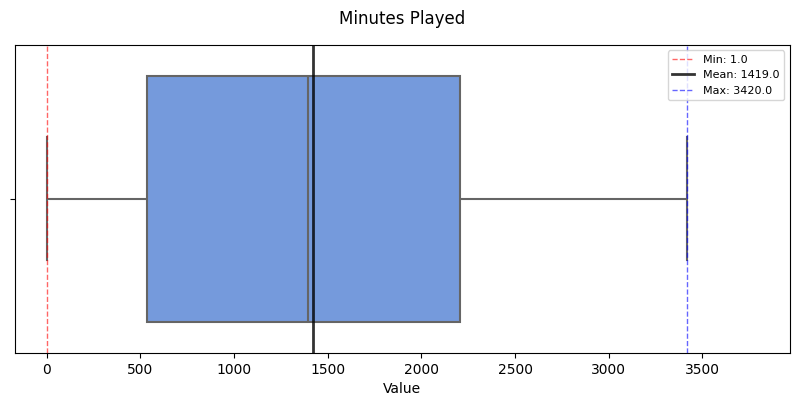

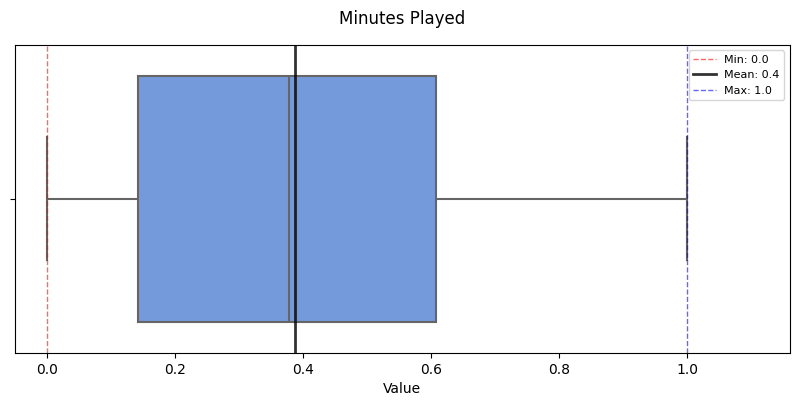

In [30]:
DISCRETE_COLUMN_LIST = [
    "Age",
    "Born",
    "Match Played",
    "Match Started",
    "Goals",
    "Assists",
    "Goals + Assists",
    "Non-Penality Goals",
    "Penalty Kick Goals",
    "Penalty Kick Attempted",
    "Yellow Cards",
    "Red Cards",
    "Experience Level", 
    "Penalty Kicker"
]

target_cols = ["Match Started", "Minutes Played"]
for column in target_cols:
    discrete = column in DISCRETE_COLUMN_LIST
    plot_boxplot(train_df, column_name=column, color="cornflowerblue")
    plot_boxplot(temp_df, column_name=column, color="cornflowerblue")
    

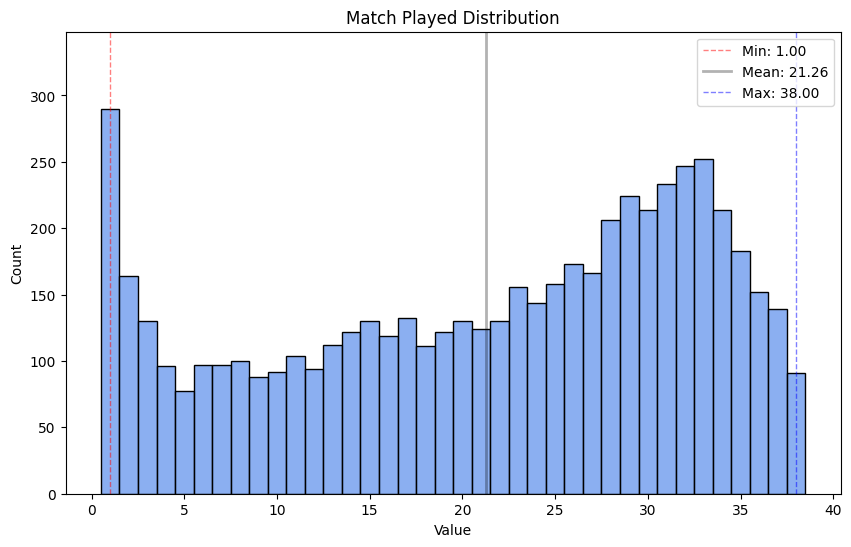

In [ ]:
plot_distribution(train_df, column_name="Match Played", color="cornflowerblue", discrete=True)

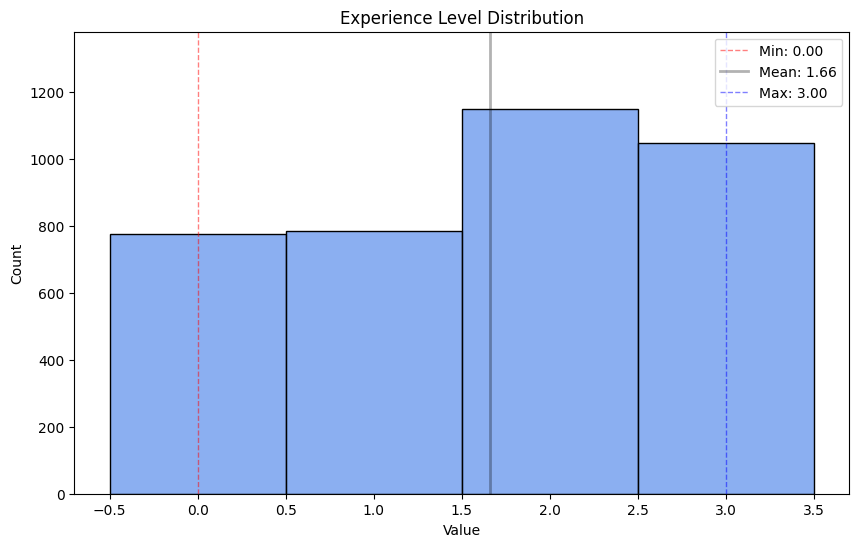

In [27]:
plot_distribution(temp_df, column_name="Experience Level", color="cornflowerblue", discrete=True)

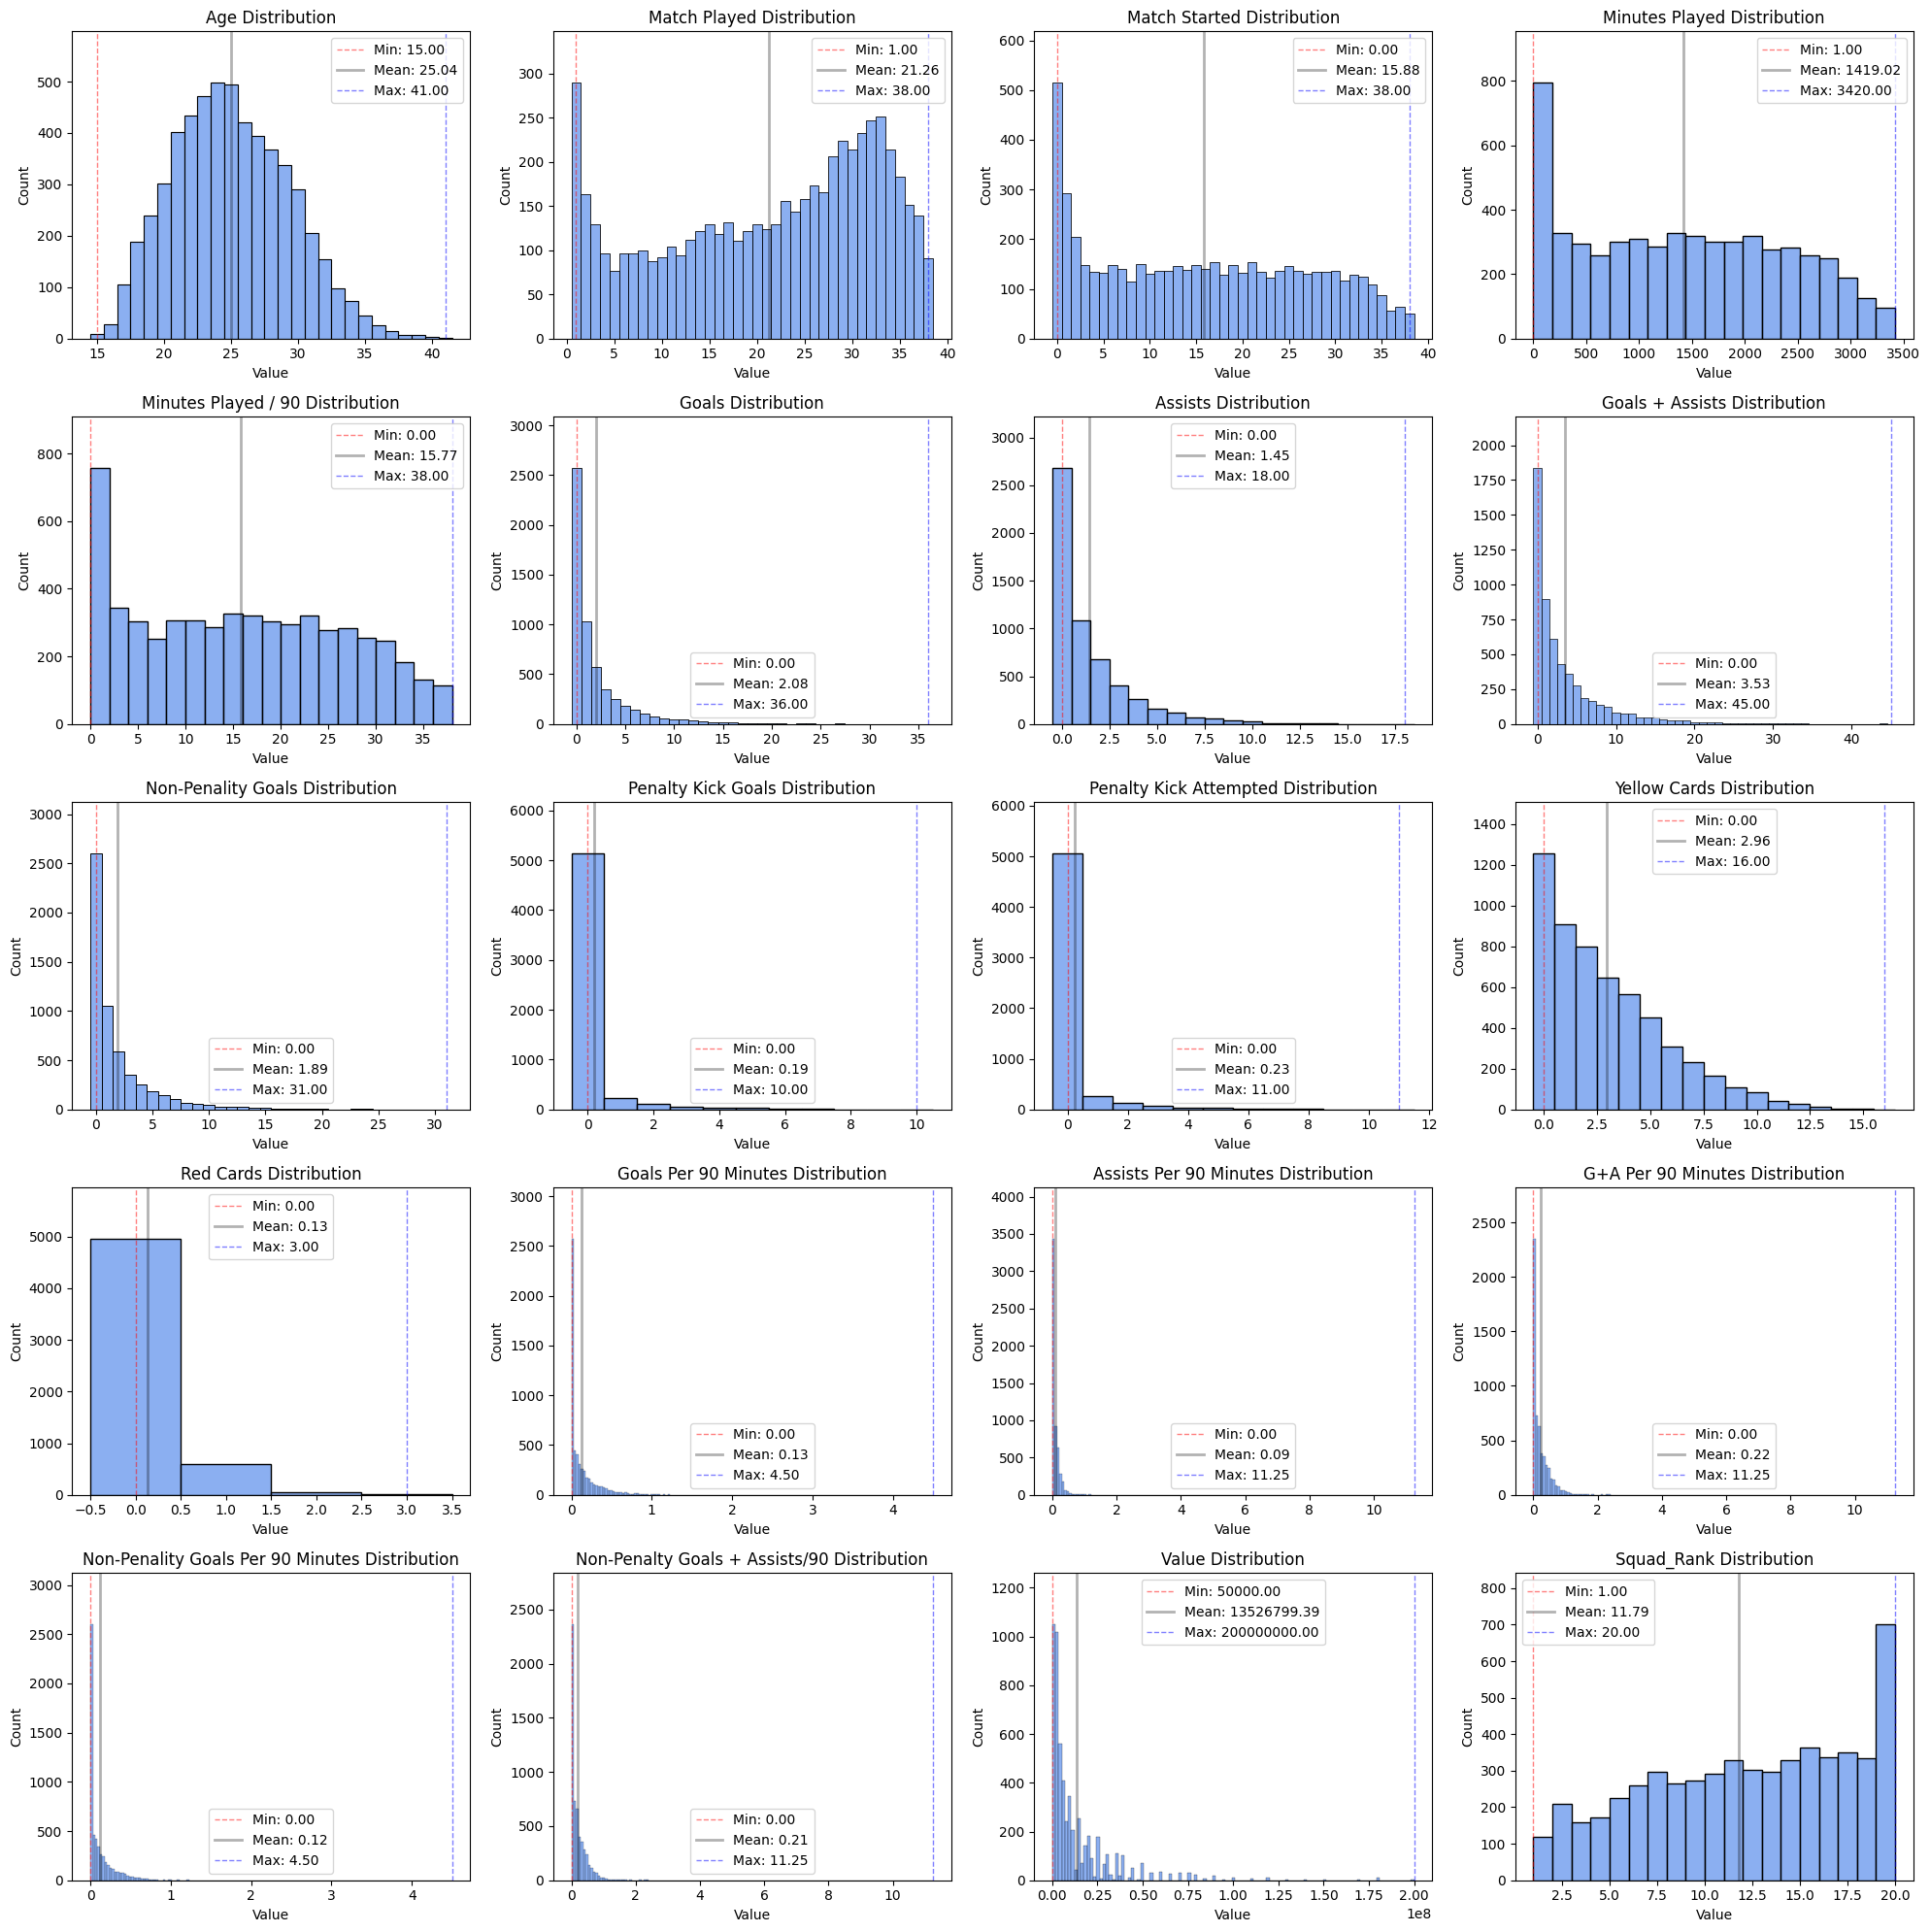

In [17]:
plot_entire_distribution(train_df, color="cornflowerblue")

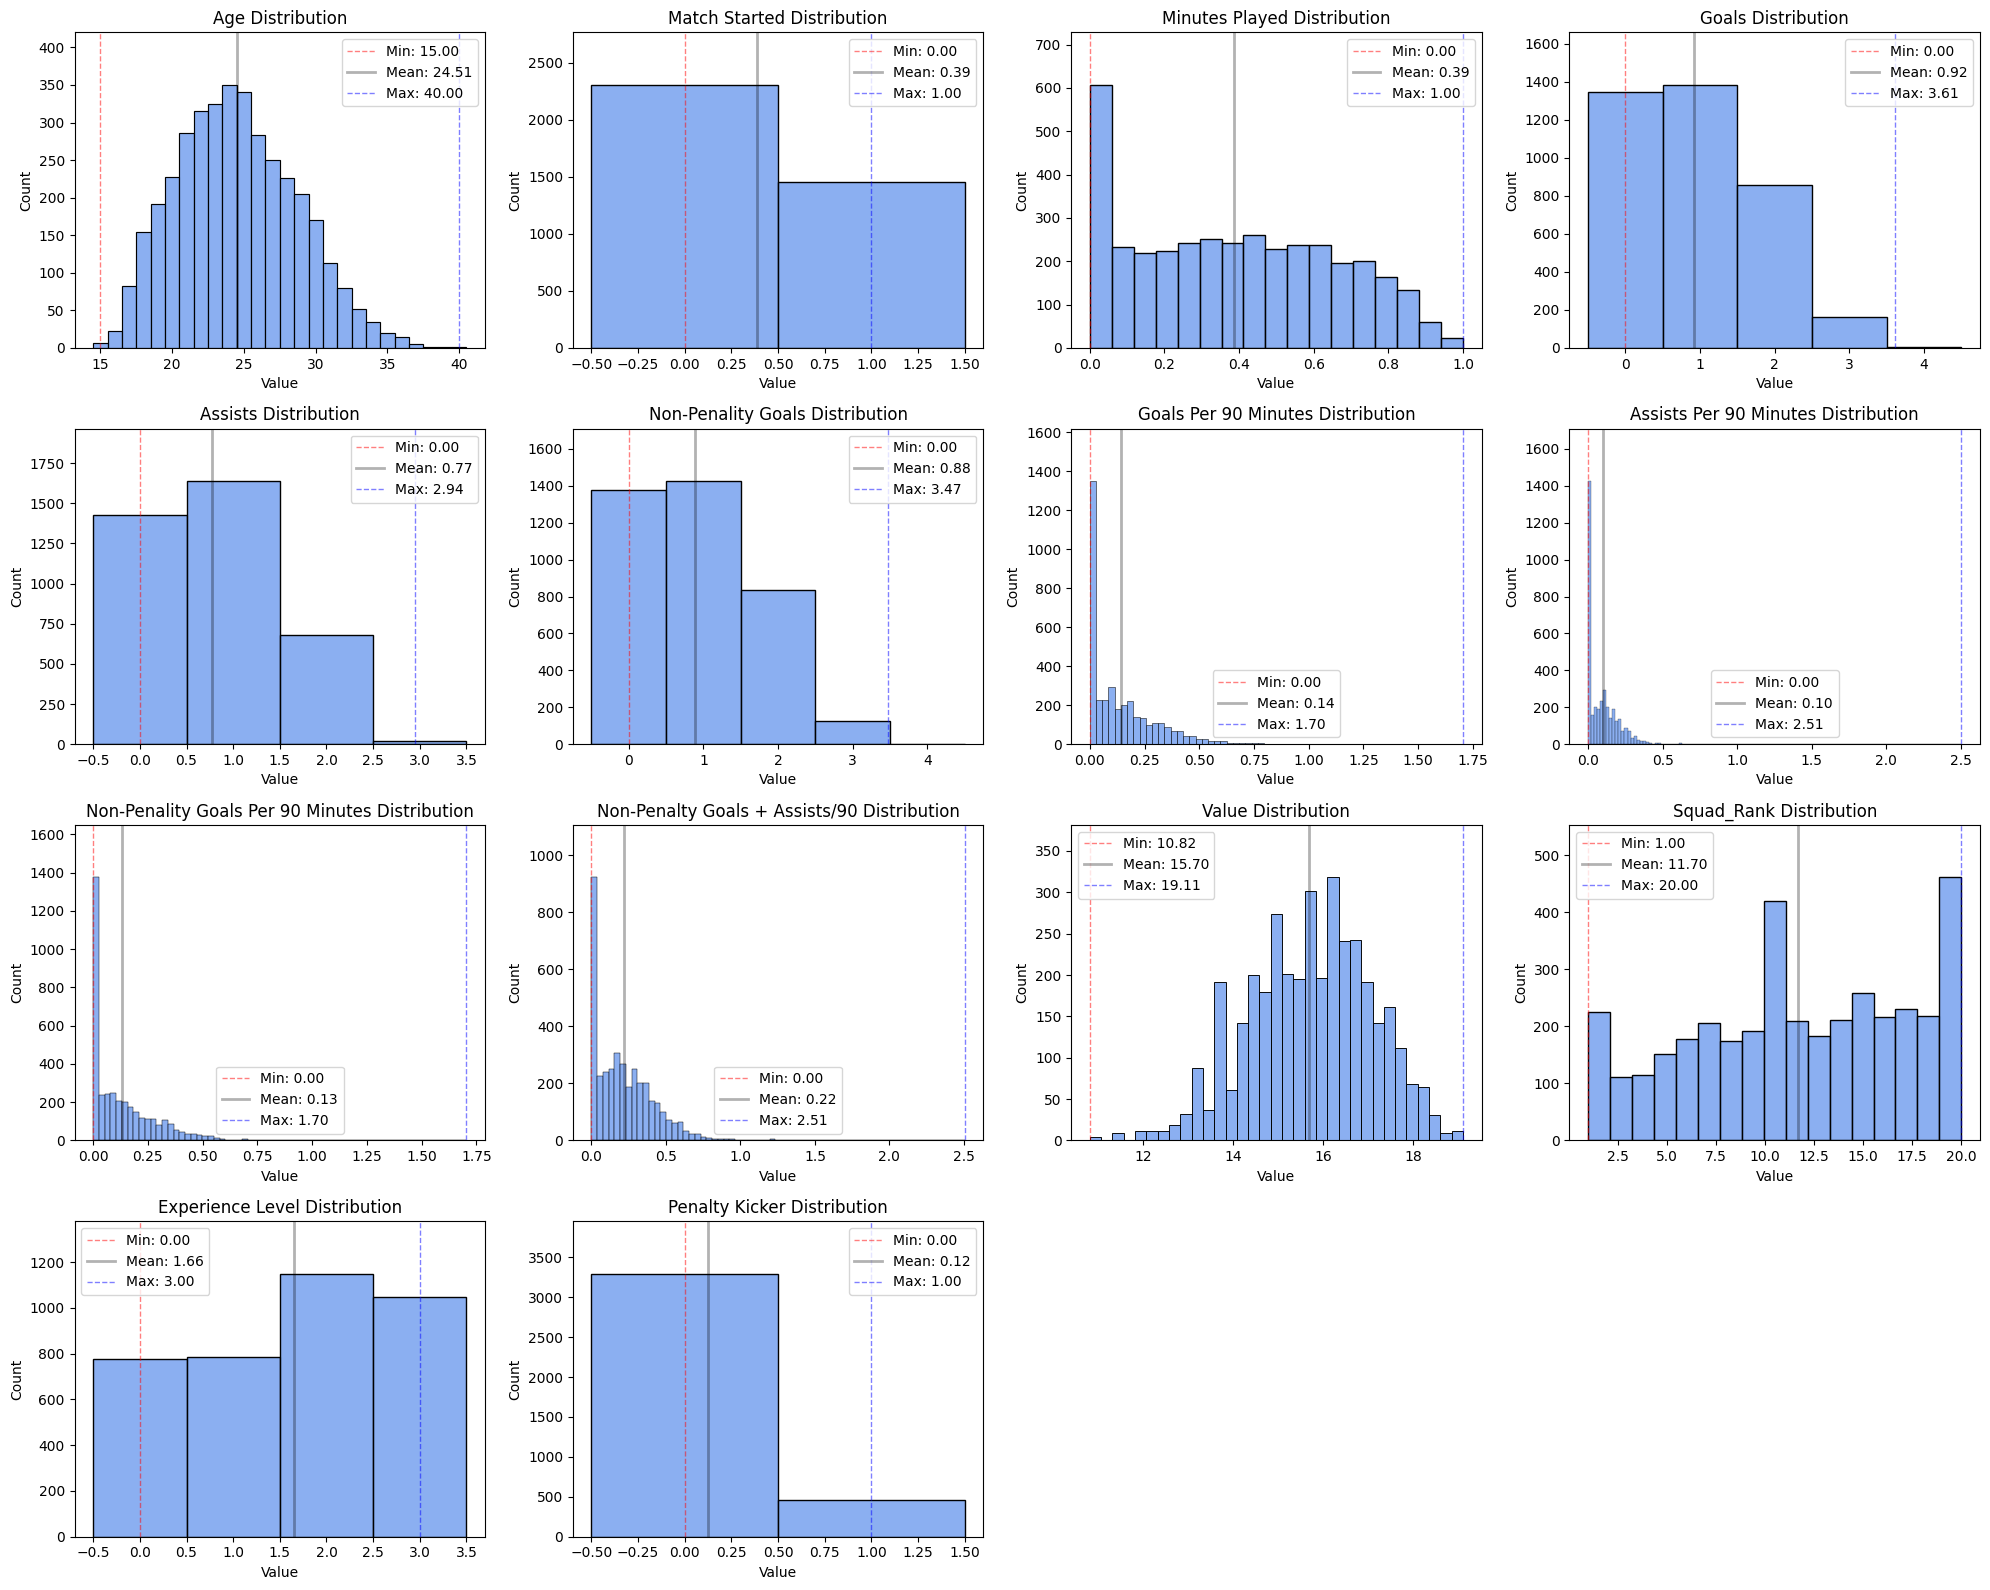

In [18]:
plot_entire_distribution(temp_df, color="cornflowerblue")